--- EDA: Customer Churn Distribution ---


/tmp/ipykernel_1224/3149176017.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'])


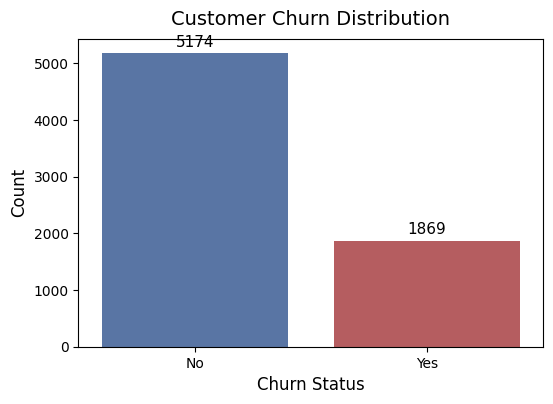

In [1]:
# 1. Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# PART 1: DATA EXPLORATION (EDA)
# ---------------------------------------------------------

# Load the Dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("--- EDA: Customer Churn Distribution ---")
# Visualize the distribution of the target variable (Churn)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette=['#4C72B0', '#C44E52'])
plt.title('Customer Churn Distribution', fontsize=14, pad=10)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

DATA PREPROCESSING

In [2]:
# ---------------------------------------------------------
# PART 2: DATA PREPROCESSING
# ---------------------------------------------------------

# Drop customerID
df = df.drop('customerID', axis=1)

# Fix TotalCharges and drop missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Separate Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Encode Categorical Data
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split (80/20 Split) - UPDATED
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling (CRITICAL FOR KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


--- Generating KNN Diagram (Testing K values 1 to 15) ---


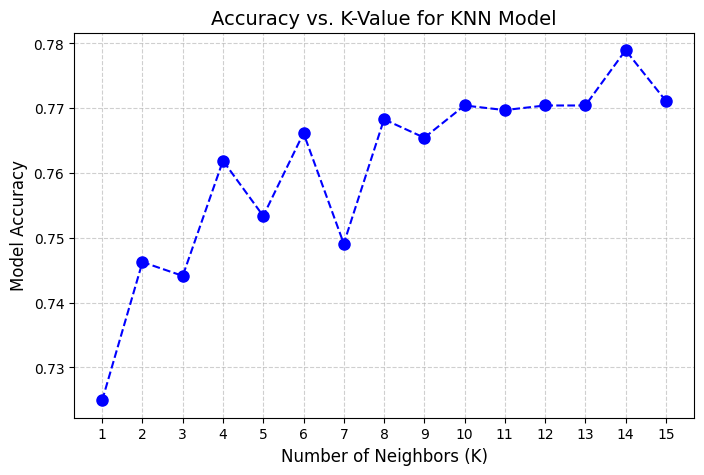

In [3]:
# ---------------------------------------------------------
# PART 3: THE "KNN DIAGRAM" (Finding the best K)
# ---------------------------------------------------------
print("\n--- Generating KNN Diagram (Testing K values 1 to 15) ---")
accuracies = []
k_values = range(1, 16)

# Test every K from 1 to 15 to see which is most accurate
for k in k_values:
    temp_knn = KNeighborsClassifier(n_neighbors=k)
    temp_knn.fit(X_train_scaled, y_train)
    temp_pred = temp_knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, temp_pred))

# Plot the K-Value Diagram
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='blue', markersize=8)
plt.title('Accuracy vs. K-Value for KNN Model', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Model Accuracy', fontsize=12)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


--- Training Final KNN Model with K=14 (accuracy=0.7790) ---

=== KNN Final Text Results ===
Accuracy Score: 77.90%

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.49      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407


--- Confusion Matrix Diagram ---


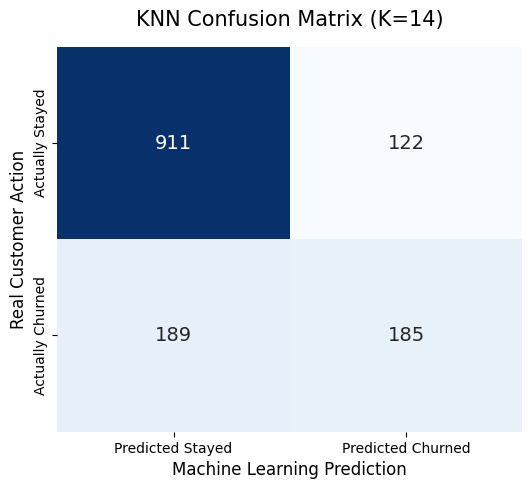

In [4]:
# ---------------------------------------------------------
# PART 4: FINAL MODEL & CONFUSION MATRIX DIAGRAM
# ---------------------------------------------------------
# Best K is selected empirically from the accuracy sweep in Part 3,
# not assumed — this guarantees it always matches the graph.
best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\n--- Training Final KNN Model with K={best_k} (accuracy={best_acc:.4f}) ---")

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)

print("\n=== KNN Final Text Results ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix Diagram
print("\n--- Confusion Matrix Diagram ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
# Use seaborn heatmap to make it look professional
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actually Stayed', 'Actually Churned'],
            annot_kws={"size": 14})

plt.title(f'KNN Confusion Matrix (K={best_k})', fontsize=15, pad=15)
plt.xlabel('Machine Learning Prediction', fontsize=12)
plt.ylabel('Real Customer Action', fontsize=12)
plt.show()